In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("Dataset/Delivery_prediction_Dataset_.xlsx")

In [2]:
df.head()

,delivery_id,delivery_partner,order_date,delivery_date,state,city,package_type,vehicle_type,delivery_mode,weather_condition,...,address_verified,payment_method,fuel_level,vehicle_breakdown,delivery_attempts,holiday,delivery_cost_ngn,failure_reason,delivery_status,delivery_failure
0,DLV000001,Jumia Logistics,2025-01-01,2025-01-02,Oyo,Ibadan,Electronics,Bike,Standard,Sunny,...,No,Cash on Delivery,High,Yes,3,Yes,39321,Flood,Failed,1
1,DLV000002,Jumia Logistics,2025-01-01,2025-01-02,FCT,Garki,Food,Bike,Standard,Sunny,...,Yes,Transfer,Medium,No,3,No,25196,NaN,Delivered,0
2,DLV000003,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Food,Bike,Standard,Harmattan,...,Yes,Transfer,Medium,No,3,No,40452,NaN,Delivered,0
3,DLV000004,Kobo360,2025-01-01,2025-01-02,Oyo,Ibadan,Food,Bike,Standard,Heavy Rain,...,No,Transfer,Medium,No,3,Yes,12402,Customer Not Home,Failed,1
4,DLV000005,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Documents,Bike,Standard,Harmattan,...,Yes,Transfer,High,Yes,1,No,9724,NaN,Delivered,0


In [3]:
def eda_summary(df):
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.count(),
        'null_count': df.isnull().sum(),
        'null_pct': (df.isnull().mean() * 100).round(2),
        'unique': df.nunique(),
        'unique_pct': (df.nunique() / len(df) * 100).round(2),
        'duplicated_count': df.duplicated().sum(), 
        'duplicated_pct': (df.duplicated().mean() * 100).round(2) 
    })
    num_stats = df.describe().T[['mean','std','min','max']]
    summary = summary.join(num_stats)
    
    return summary

In [4]:
eda_summary(df)

,dtype,non_null,null_count,null_pct,unique,unique_pct,duplicated_count,duplicated_pct,mean,std,min,max
delivery_id,object,10000,0,0.00,10000,100.00,0,0.0,NaN,NaN,NaN,NaN
delivery_partner,object,10000,0,0.00,4,0.04,0,0.0,NaN,NaN,NaN,NaN
order_date,object,10000,0,0.00,1,0.01,0,0.0,NaN,NaN,NaN,NaN
delivery_date,object,10000,0,0.00,1,0.01,0,0.0,NaN,NaN,NaN,NaN
state,object,10000,0,0.00,6,0.06,0,0.0,NaN,NaN,NaN,NaN
city,object,10000,0,0.00,10,0.10,0,0.0,NaN,NaN,NaN,NaN
package_type,object,10000,0,0.00,3,0.03,0,0.0,NaN,NaN,NaN,NaN
vehicle_type,object,10000,0,0.00,3,0.03,0,0.0,NaN,NaN,NaN,NaN
delivery_mode,object,10000,0,0.00,1,0.01,0,0.0,NaN,NaN,NaN,NaN
weather_condition,object,10000,0,0.00,4,0.04,0,0.0,NaN,NaN,NaN,NaN


Data Cleaning

In [5]:
# Categorical Data Entry Errors
for col in ['weather_condition', 'traffic_level', 'road_condition', 'delivery_partner']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- weather_condition ---
weather_condition
Rainy         2546
Heavy Rain    2520
Harmattan     2468
Sunny         2466
Name: count, dtype: int64

--- traffic_level ---
traffic_level
Heavy       3368
Low         3285
Moderate    3255
Hevy          92
Name: count, dtype: int64

--- road_condition ---
road_condition
Fair    3408
Good    3310
Bad     3282
Name: count, dtype: int64

--- delivery_partner ---
delivery_partner
GIG Logistics      2580
Kobo360            2514
Jumia Logistics    2484
Kwik               2422
Name: count, dtype: int64


In [ ]:
# Categorical Data Entry Errors
#updated
df['traffic_level'] = df['traffic_level'].replace({'Hevy': 'Heavy'})

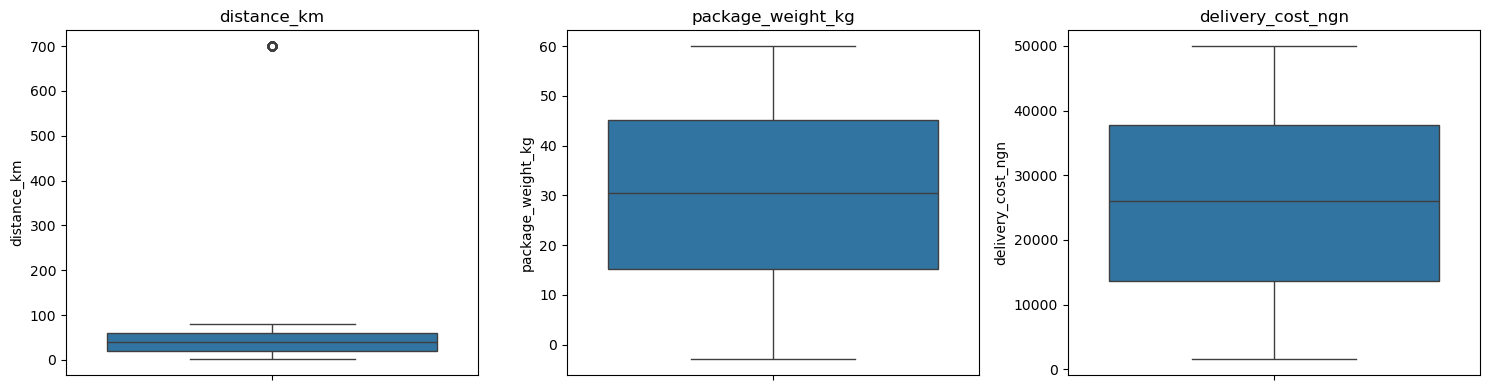

In [7]:
#Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['distance_km', 'package_weight_kg', 'delivery_cost_ngn']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [8]:
#Constant value: distance_km = 700 found in multiple rows
cols_to_check = ['distance_km', 'expected_time_hours', 'actual_time_hours',
                  'delivery_cost_ngn', 'city', 'state', 'delivery_partner']
df[df['distance_km'] > 200][cols_to_check]

count_700 = (df['distance_km'] == 700).sum()
print(f"Affected rows: {count_700} ({count_700/len(df)*100:.2f}%)")
# package_weight_kg has negative values
count_negative = (df['package_weight_kg'] < 0).sum()
print(f"Affected rows: {count_negative} ({count_negative/len(df)*100:.2f}%)")

Affected rows: 106 (1.06%)
Affected rows: 36 (0.36%)


In [9]:
#Cleaning — Outlier Removal
df = df[df['distance_km'] != 700]
df = df[df['package_weight_kg'] >= 0]

In [10]:
#data leakage
leakage_cols = ['delivery_attempts', 'actual_time_hours', 'failure_reason',
                 'delivery_status', 'vehicle_breakdown', 'delivery_id']

df = df.drop(columns=leakage_cols)

C:\Users\DELL\AppData\Local\Temp\ipykernel_5236\3800978856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette="rocket")
C:\Users\DELL\AppData\Local\Temp\ipykernel_5236\3800978856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette="rocket")
C:\Users\DELL\AppData\Local\Temp\ipykernel_5236\3800978856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette

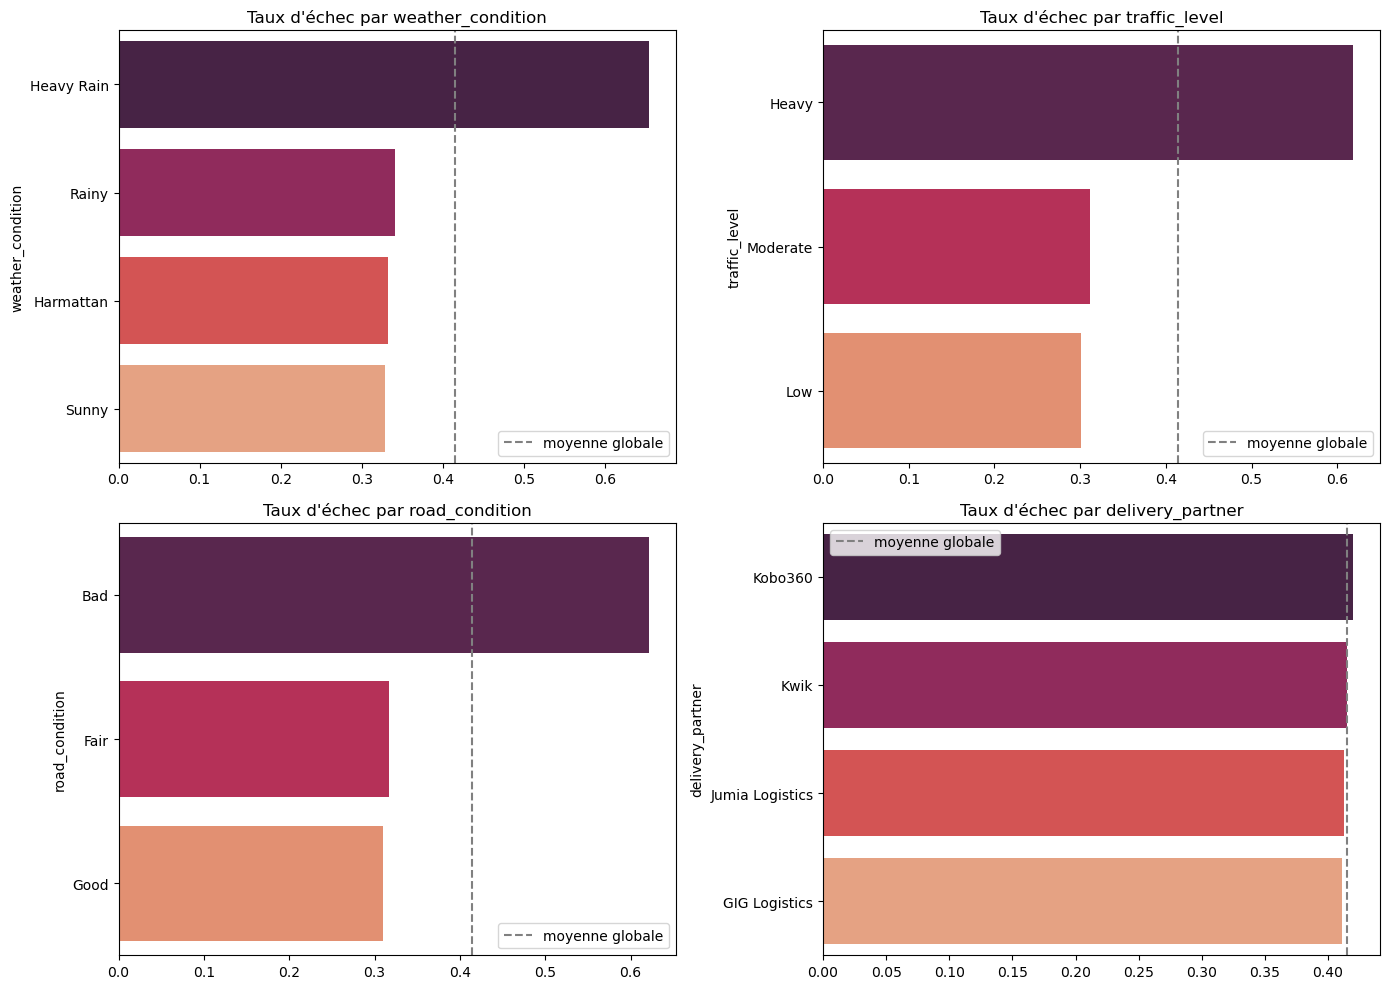

In [11]:
# EDA — Failure Rate by Categorical Feature
cat_cols = ['weather_condition', 'traffic_level', 'road_condition', 'delivery_partner']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    failure_rate = df.groupby(col)['delivery_failure'].mean().sort_values(ascending=False)
    sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[i], palette="rocket")
    axes[i].set_title(f"Taux d'échec par {col}")
    axes[i].axvline(df['delivery_failure'].mean(), color='gray', linestyle='--', label='moyenne globale')
    axes[i].legend()
plt.tight_layout()
plt.show()

### Correlation Matrix

In [12]:
df.describe ()

,distance_km,package_weight_kg,expected_time_hours,driver_experience,driver_rating,delivery_cost_ngn,delivery_failure
count,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000
mean,40.161524,30.311453,12.515774,7.371475,3.759738,25774.367823,0.414587
std,22.833668,17.310921,6.626473,4.612681,0.728614,13931.616143,0.492676
min,1.000000,0.200000,1.000000,0.000000,2.500000,1509.000000,0.000000
25%,20.400000,15.300000,6.700000,3.000000,3.100000,13687.000000,0.000000
50%,39.800000,30.600000,12.500000,7.000000,3.800000,25954.000000,0.000000
75%,59.800000,45.300000,18.275000,11.000000,4.400000,37729.500000,1.000000
max,80.000000,60.000000,24.000000,15.000000,5.000000,49999.000000,1.000000


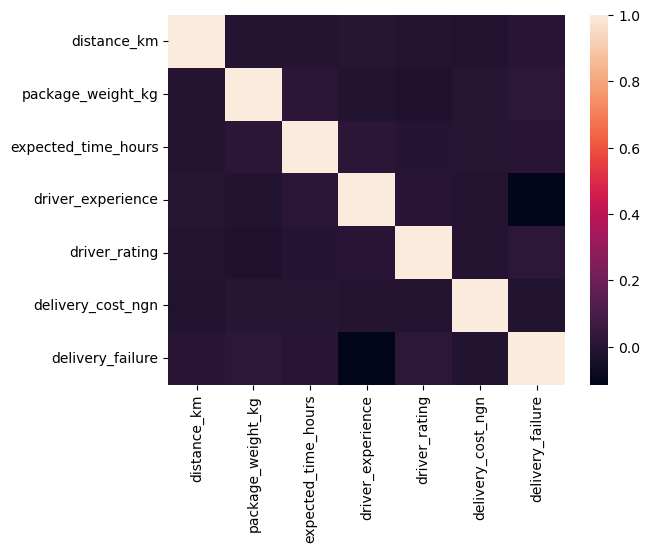

In [13]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='rocket', annot=False)
plt.show()

In [14]:
print("final Dataset:", df.shape)

final Dataset: (9858, 24)


In [15]:
df.head()

,delivery_partner,order_date,delivery_date,state,city,package_type,vehicle_type,delivery_mode,weather_condition,traffic_level,...,driver_id,driver_experience,driver_rating,customer_available,address_verified,payment_method,fuel_level,holiday,delivery_cost_ngn,delivery_failure
0,Jumia Logistics,2025-01-01,2025-01-02,Oyo,Ibadan,Electronics,Bike,Standard,Sunny,Heavy,...,DRV0424,12,3.9,Yes,No,Cash on Delivery,High,Yes,39321,1
1,Jumia Logistics,2025-01-01,2025-01-02,FCT,Garki,Food,Bike,Standard,Sunny,Low,...,DRV0349,13,3.8,Yes,Yes,Transfer,Medium,No,25196,0
2,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Food,Bike,Standard,Harmattan,Moderate,...,DRV0286,15,3.9,Yes,Yes,Transfer,Medium,No,40452,0
3,Kobo360,2025-01-01,2025-01-02,Oyo,Ibadan,Food,Bike,Standard,Heavy Rain,Low,...,DRV0379,2,3.1,No,No,Transfer,Medium,Yes,12402,1
4,Jumia Logistics,2025-01-01,2025-01-02,Kano,Kano,Documents,Bike,Standard,Harmattan,Moderate,...,DRV0075,13,3.5,Yes,Yes,Transfer,High,No,9724,0


### Apply one-hot encoding to categorical features

In [16]:
# Identify categorical columns automatically (or list them manually)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Option A: pandas get_dummies (quick, good for one-off scripts)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Option B: sklearn OnehotEncoder (better for production pipelines,
# # since it can be saved and reused on new/test data consistently)
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoded_array = ohe.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(categorical_cols))

df_final = pd.concat([df.drop(columns=categorical_cols).reset_index(drop=True), 
                      encoded_df.reset_index(drop=True)], axis=1)

Categorical columns: ['delivery_partner', 'order_date', 'delivery_date', 'state', 'city', 'package_type', 'vehicle_type', 'delivery_mode', 'weather_condition', 'traffic_level', 'road_condition', 'driver_id', 'customer_available', 'address_verified', 'payment_method', 'fuel_level', 'holiday']


### Train/test split data set

In [17]:
from sklearn.model_selection import train_test_split
import pandas as pd


df = pd.read_excel("Dataset/Delivery_prediction_Dataset_.xlsx")

X = df.drop(columns=['driver_rating'])
y = df['driver_rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # keeps class proportions balanced — use for classification, drop for regression
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")



Train shape: (8000, 29), Test shape: (2000, 29)


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Baseline Modeling + Feature importance

##### Sorting for ID types that shouldn't be encoded as a feature

In [19]:
# find the culprit column(s)
print(X_train.dtypes)

delivery_id             object
delivery_partner        object
order_date              object
delivery_date           object
state                   object
city                    object
package_type            object
vehicle_type            object
delivery_mode           object
weather_condition       object
traffic_level           object
road_condition          object
distance_km            float64
package_weight_kg      float64
expected_time_hours    float64
actual_time_hours      float64
driver_id               object
driver_experience        int64
customer_available      object
address_verified        object
payment_method          object
fuel_level              object
vehicle_breakdown       object
delivery_attempts        int64
holiday                 object
delivery_cost_ngn        int64
failure_reason          object
delivery_status         object
delivery_failure         int64
dtype: object


##### Drop pure identifier / leakage columns

In [20]:
drop_cols = ['delivery_id', 'driver_id', 'order_date', 'delivery_date', 'failure_reason', 'delivery_status', 'delivery_failure', 'actual_time_hours']
X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

##### Encode genuine categorical features

In [21]:
categorical_cols = X_train.select_dtypes(include='object',).columns.tolist()

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# align columns in case train/test have different categories present
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [22]:
# Check if y_train contains continuous values since RandomForestClassifier only works with discrete categories
print(y_train.dtype)
print(y_train.unique()[:10])

float64
[2.7 3.7 4.2 4.  3.9 4.5 5.  4.9 4.1 2.9]


In [23]:
# Since we meant to predict delivery failure (classification), we need to ensure that y_train and y_test are categorically encoded (0 or 1) 
y_train = df.loc[X_train.index, 'delivery_failure']
y_test = df.loc[X_test.index, 'delivery_failure']

Accuracy: 0.9705
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1175
           1       1.00      0.93      0.96       825

    accuracy                           0.97      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.97      0.97      0.97      2000

traffic_level_Heavy             0.077037
delivery_attempts               0.070963
road_condition_Bad              0.065534
weather_condition_Heavy Rain    0.063396
address_verified_Yes            0.061231
vehicle_breakdown_Yes           0.053951
customer_available_No           0.053668
customer_available_Yes          0.052931
vehicle_breakdown_No            0.050880
driver_experience               0.050079
address_verified_No             0.048245
delivery_cost_ngn               0.030563
package_weight_kg               0.030264
distance_km                     0.029872
expected_time_hours             0.028263
dtype: float64


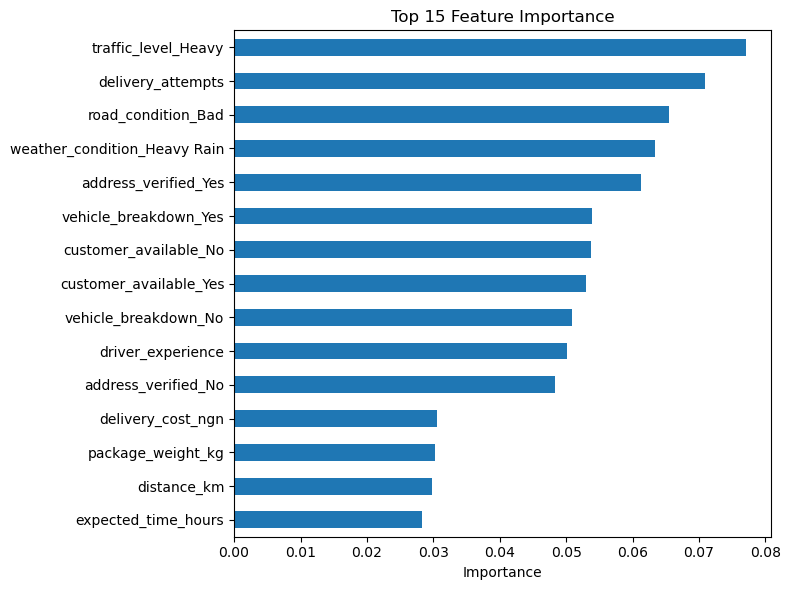

In [24]:
from sklearn.ensemble import RandomForestClassifier # or RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Baseline model - simple, fast, interpretable
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))

importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()